In [1]:
pip install xarray netCDF4 matplotlib cartopy


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/21.3 MB ? eta -:--:--
   -------------- ------------------------- 7.9/21.3 MB 40.7 MB/s eta 0:00:01
   ------------------------------- -------- 16.5/21.3 MB 41.7 MB/s eta 0:00:01
   ---------------------------------------- 21.3/21.3 MB 37.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.0 MB 49.2 MB/s eta 0:00:01
   -------------- ------------------------- 3.9/11.0 MB 9.0 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.0 MB 12.9 MB/s eta 0:00:01
   ------------------------------ --------- 8.4/11.0 MB 10.6 MB/s eta 0:00:01
   ---------------------------------- ----- 9.4/11.0 MB 9.8 MB/s eta 0:00:01
   ---------------------------------- ----- 9.4/11.0 MB 9.8 MB/s eta 0:00:01
   ---------------------------------- ----- 9.4/11.0 MB 9.8 MB/s eta 0:00:01
   -

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Delhi bounding box: LAT (28.382605902840123, 28.932087511129726), LON (76.78368777866804, 77.38753299275338)
ERA5 grid cells in Delhi — lat: [28.75 28.5 ]
ERA5 grid cells in Delhi — lon: [77.   77.25]
Total ERA5 cells: 4

Stagnant count shape: (20, 2, 2)
Months present: [ 1  2 10 11 12]
Years present:  [2021 2022 2023 2024]

Sample values (Oct 2021):
[[[30 30]
  [30 30]]]

Climatology (mean stagnant days/month per cell):
[[[27.25 27.  ]
  [27.75 26.75]]

 [[24.5  23.5 ]
  [24.75 24.5 ]]

 [[30.5  30.  ]
  [30.   29.75]]

 [[29.75 29.5 ]
  [29.75 29.75]]

 [[28.25 28.  ]
  [28.75 27.75]]]

[2021-10] ERA5 raw anomaly values: [-0.5   0.    0.    0.25]
  range: -0.500 to 0.250 stagnant days


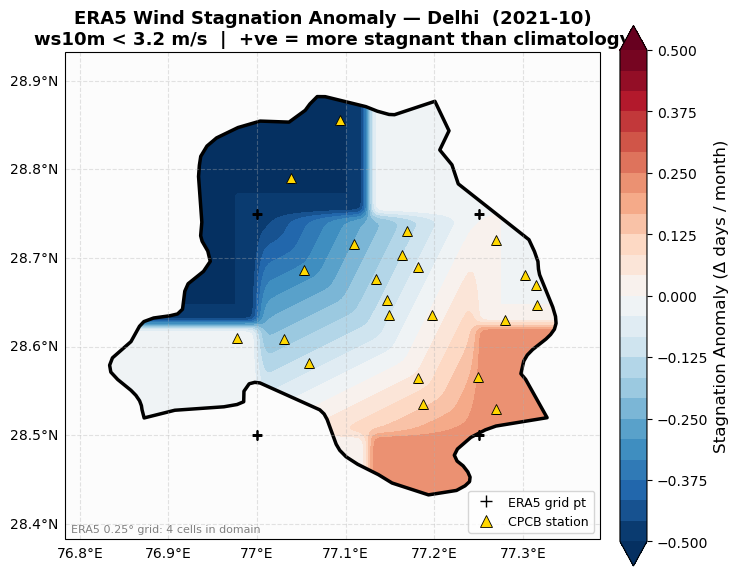


[2021-11] ERA5 raw anomaly values: [-0.75 -1.5  -0.75 -0.75]
  range: -1.500 to -0.750 stagnant days


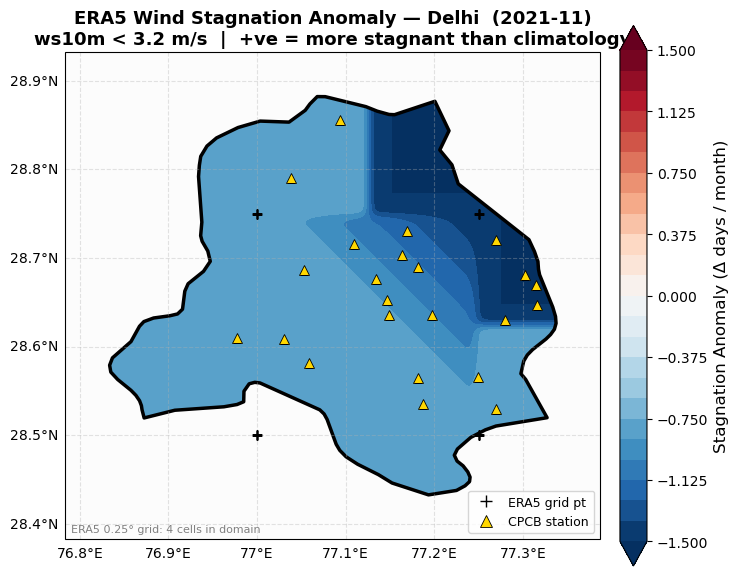


[2021-12] ERA5 raw anomaly values: [0.75 0.   0.25 0.25]
  range: 0.000 to 0.750 stagnant days


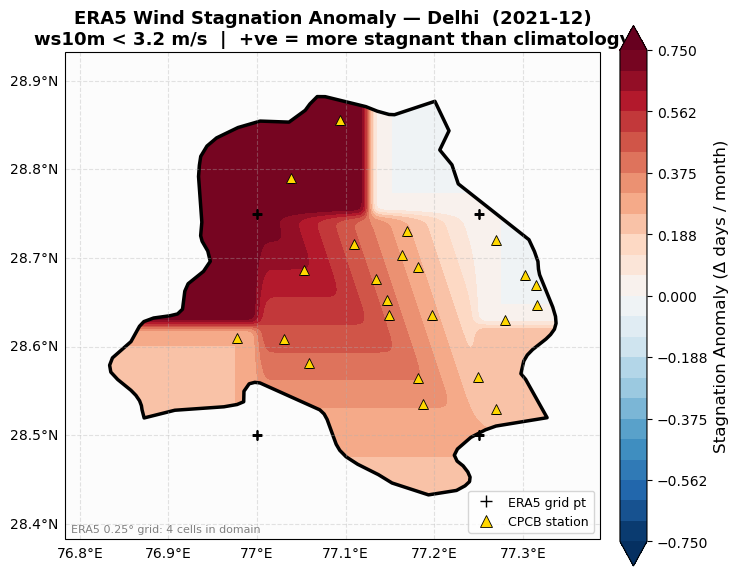


[2021-01] ERA5 raw anomaly values: [-1.25 -2.   -1.75 -1.75]
  range: -2.000 to -1.250 stagnant days


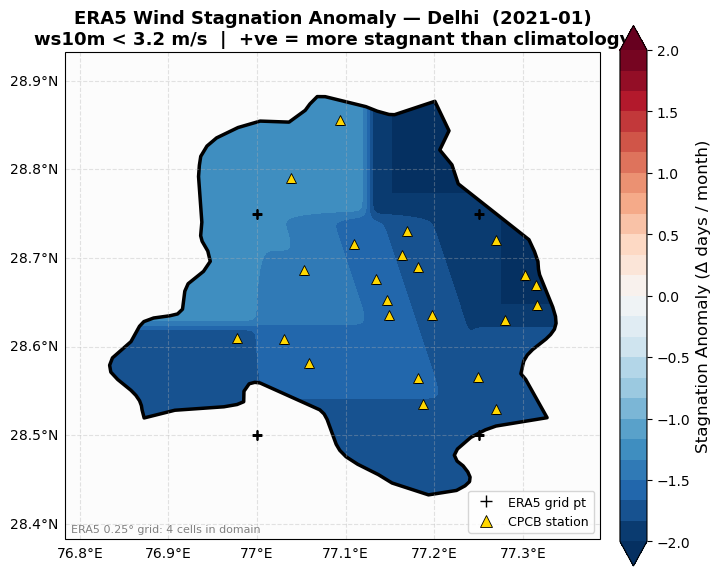


[2021-02] ERA5 raw anomaly values: [3.5  3.5  3.25 3.5 ]
  range: 3.250 to 3.500 stagnant days


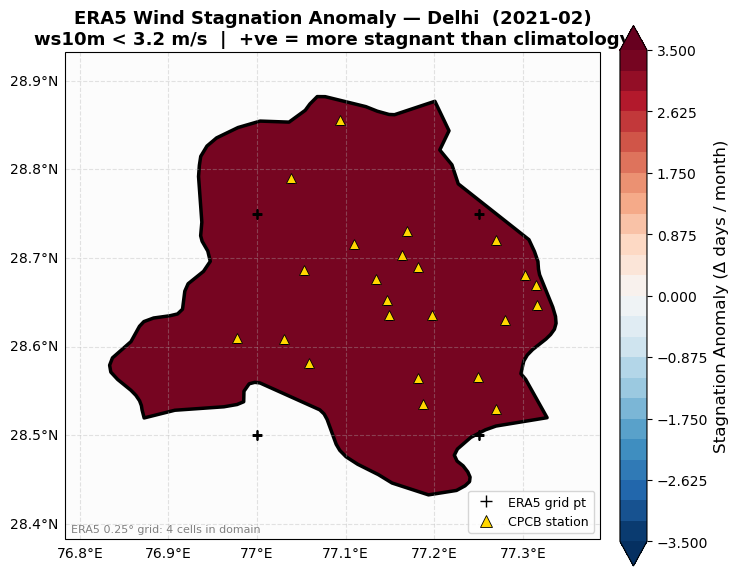


[2022-10] ERA5 raw anomaly values: [-0.5  -2.   -2.   -2.75]
  range: -2.750 to -0.500 stagnant days


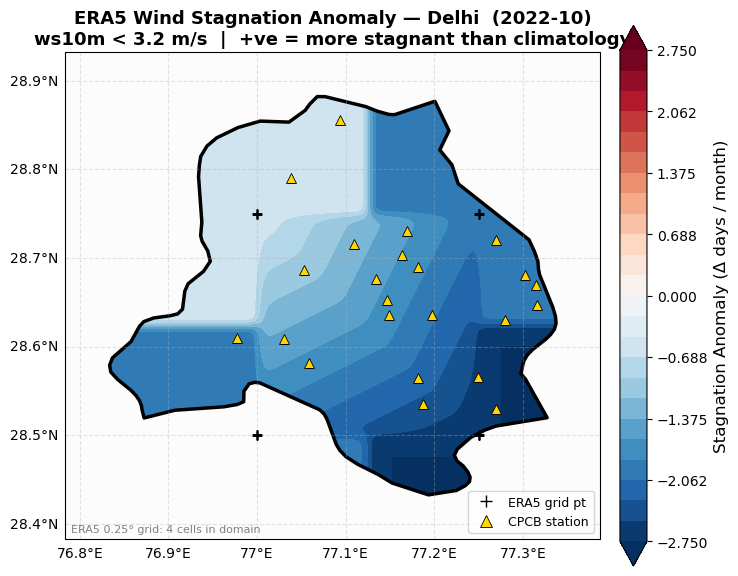


[2022-11] ERA5 raw anomaly values: [0.25 0.5  0.25 0.25]
  range: 0.250 to 0.500 stagnant days


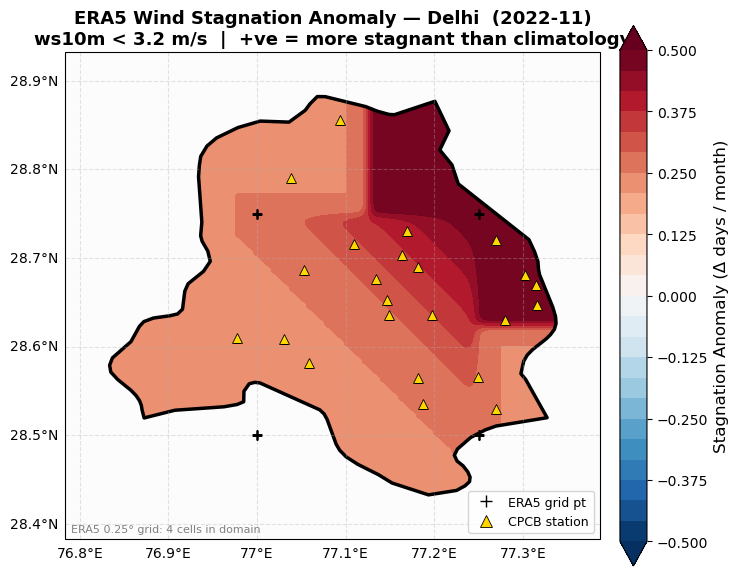


[2022-12] ERA5 raw anomaly values: [-3.25 -3.   -2.75 -3.75]
  range: -3.750 to -2.750 stagnant days


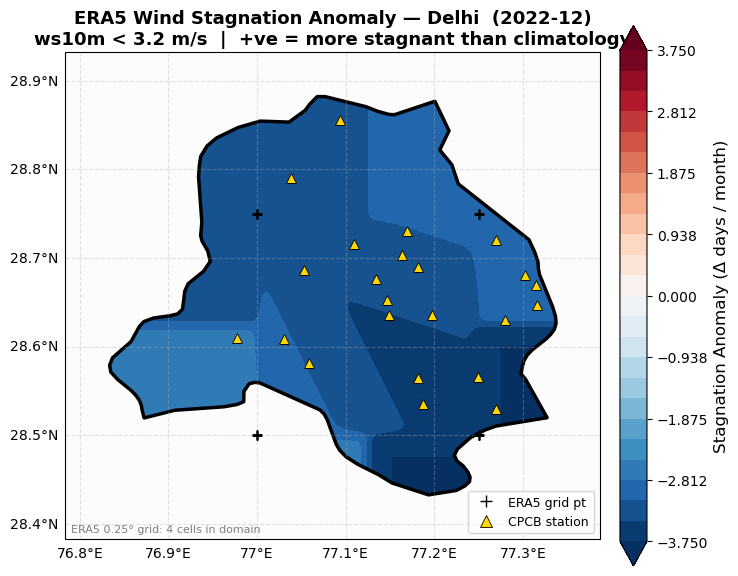


[2022-01] ERA5 raw anomaly values: [-2.25 -2.   -0.75 -1.75]
  range: -2.250 to -0.750 stagnant days


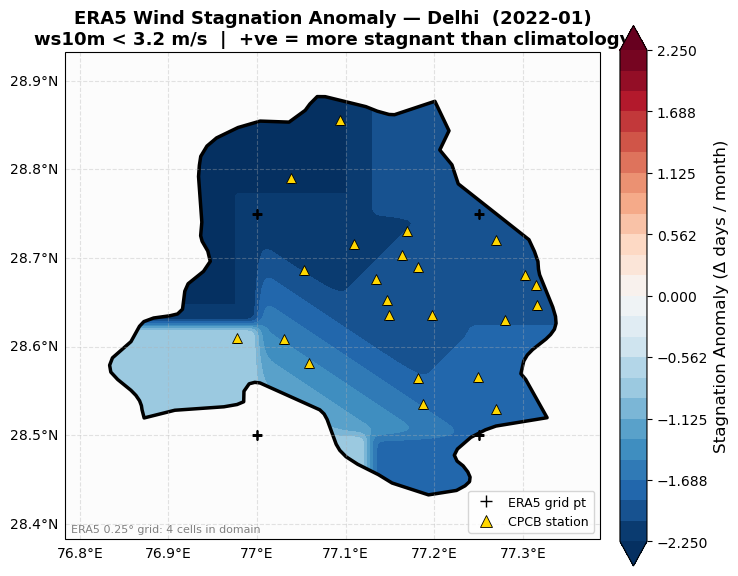


[2022-02] ERA5 raw anomaly values: [-1.5  -1.5  -0.75 -0.5 ]
  range: -1.500 to -0.500 stagnant days


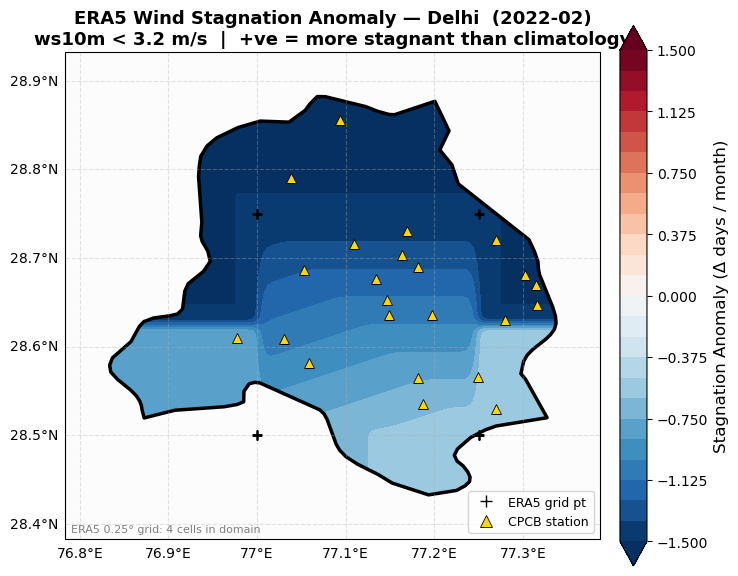


[2023-10] ERA5 raw anomaly values: [0.5  1.   1.   1.25]
  range: 0.500 to 1.250 stagnant days


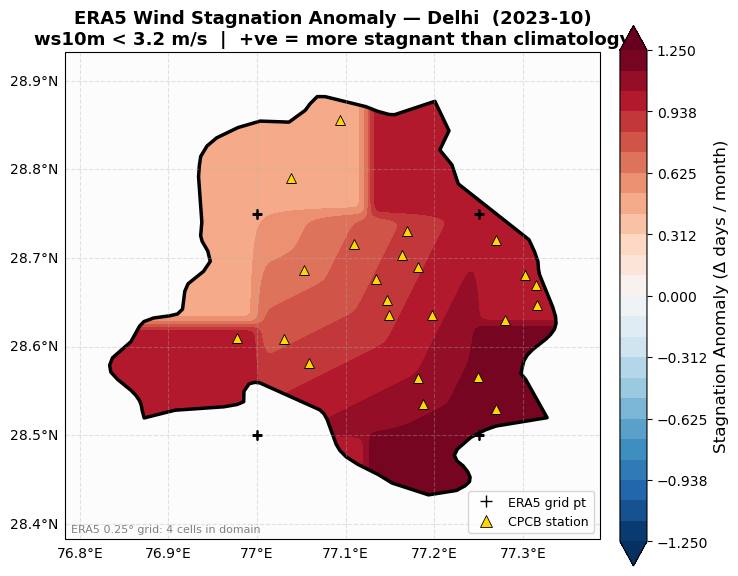


[2023-11] ERA5 raw anomaly values: [0.25 0.5  0.25 0.25]
  range: 0.250 to 0.500 stagnant days


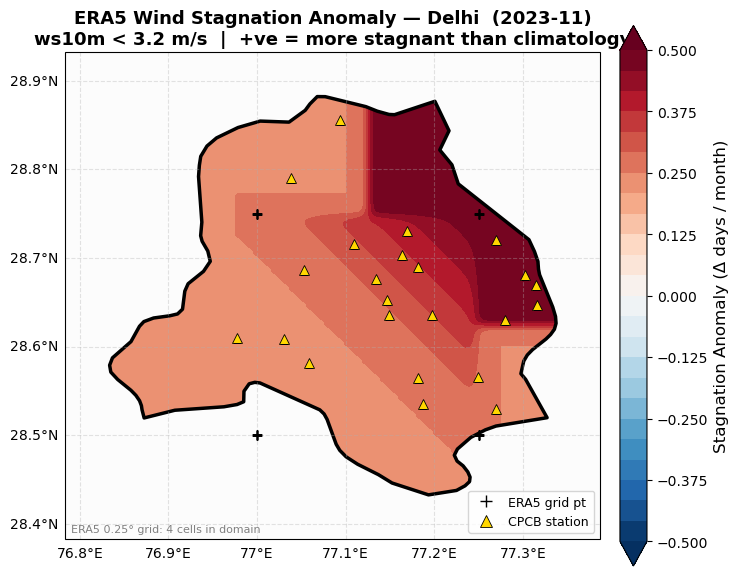


[2023-12] ERA5 raw anomaly values: [1.75 2.   1.25 2.25]
  range: 1.250 to 2.250 stagnant days


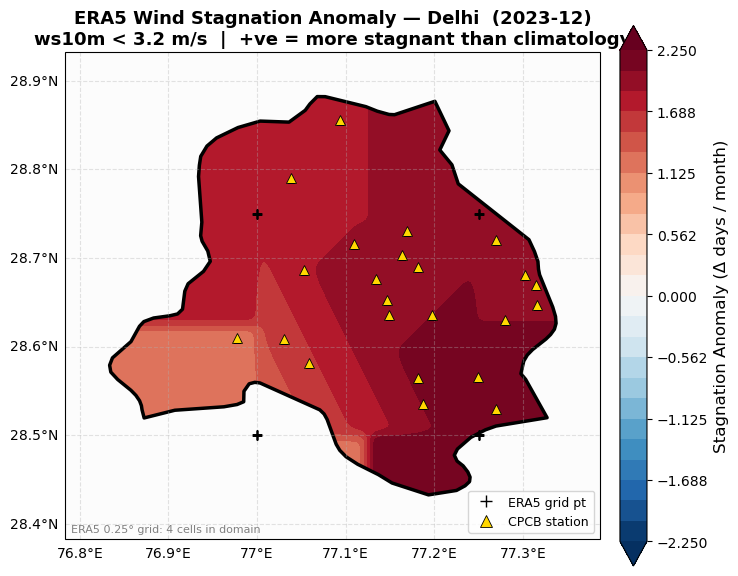


[2023-01] ERA5 raw anomaly values: [-0.25  0.   -0.75 -0.75]
  range: -0.750 to 0.000 stagnant days


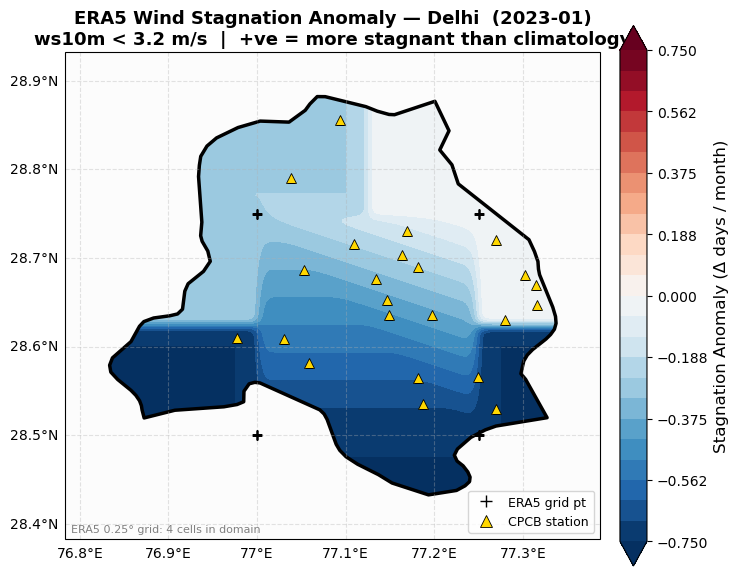


[2023-02] ERA5 raw anomaly values: [-3.5  -2.5  -3.75 -3.5 ]
  range: -3.750 to -2.500 stagnant days


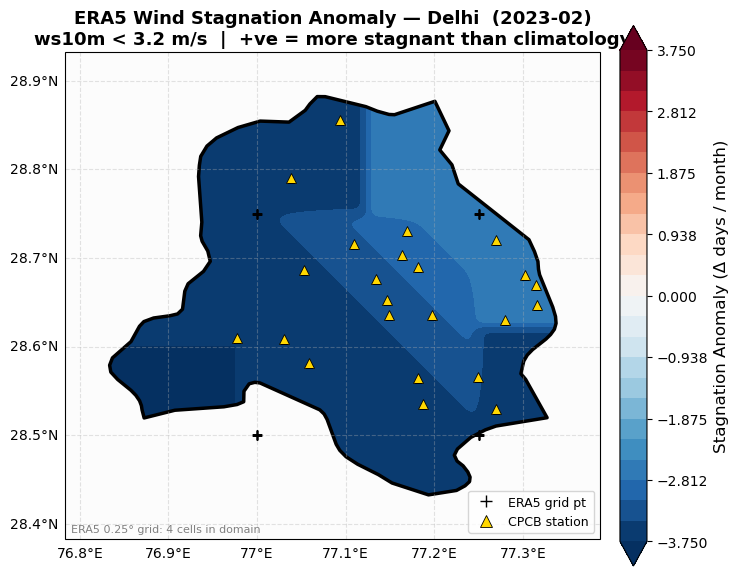


[2024-10] ERA5 raw anomaly values: [0.5  1.   1.   1.25]
  range: 0.500 to 1.250 stagnant days


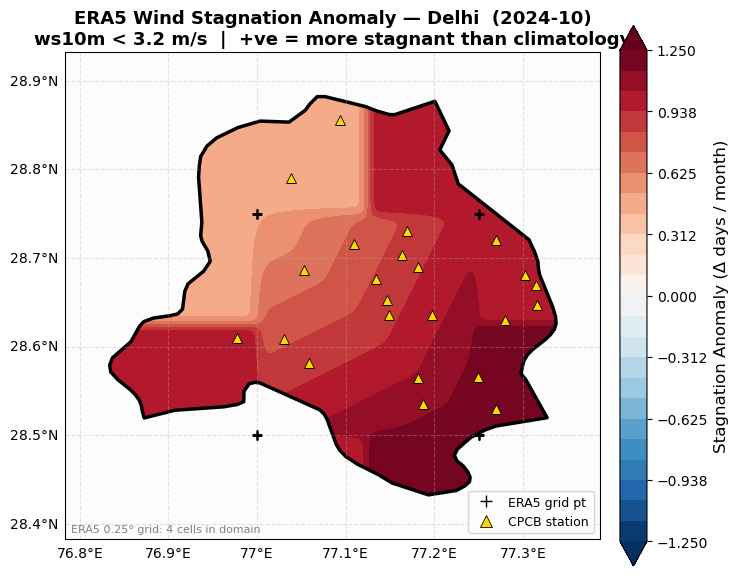


[2024-11] ERA5 raw anomaly values: [0.25 0.5  0.25 0.25]
  range: 0.250 to 0.500 stagnant days


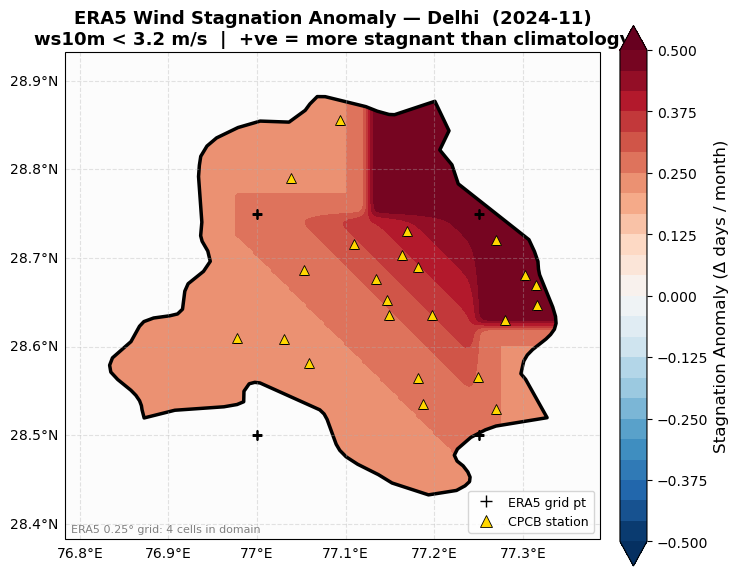


[2024-12] ERA5 raw anomaly values: [0.75 1.   1.25 1.25]
  range: 0.750 to 1.250 stagnant days


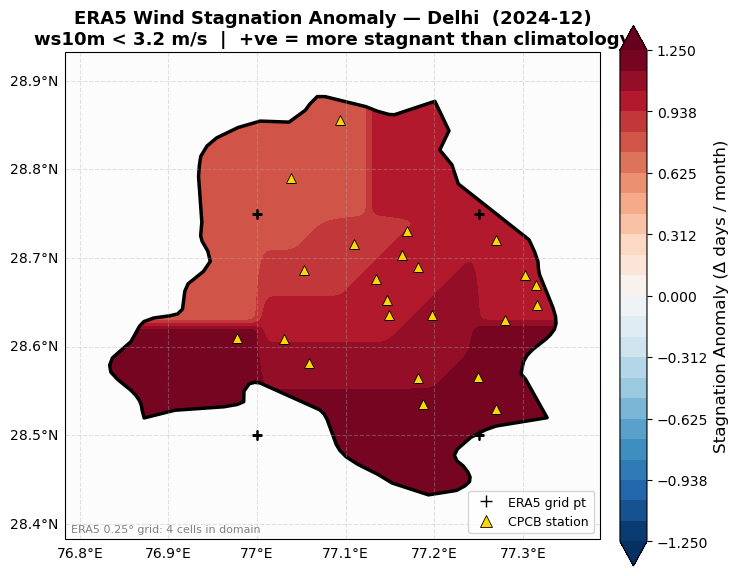


[2024-01] ERA5 raw anomaly values: [3.75 4.   3.25 4.25]
  range: 3.250 to 4.250 stagnant days


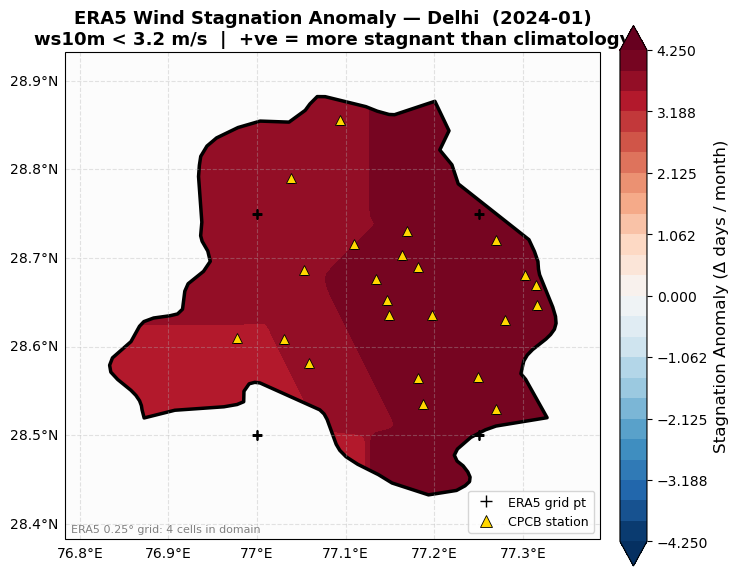


[2024-02] ERA5 raw anomaly values: [1.5  0.5  1.25 0.5 ]
  range: 0.500 to 1.500 stagnant days


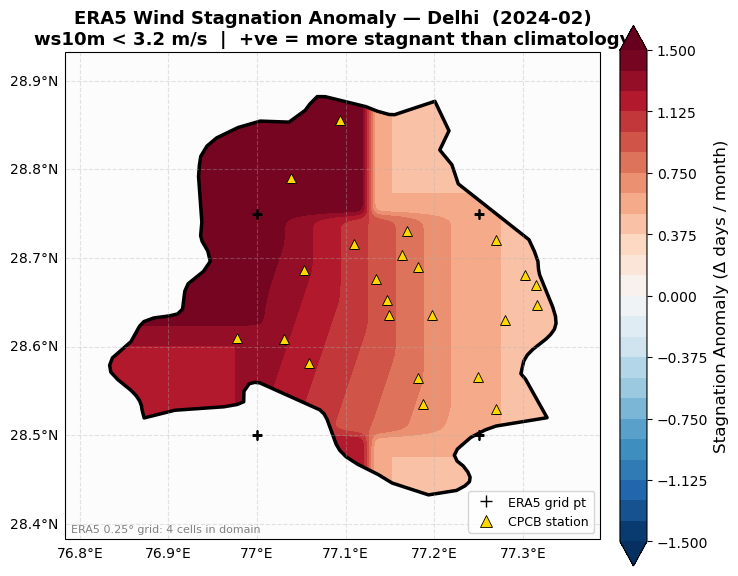

In [43]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.ops import unary_union
from matplotlib.path import Path
from matplotlib.lines import Line2D

# ============================================================
# 1) Load ERA5
# ============================================================
ds = xr.open_mfdataset(
    [
        r"D:/downloads/ERA5_WS_daily_2021.nc",
        r"D:/downloads/ERA5_WS_daily_2022_2024.nc",
    ],
    combine="by_coords"
)

# ============================================================
# 2) Load Delhi shapefile
# ============================================================
india = gpd.read_file(
    r"D:\downloads\ne_10m_admin_1_states_provinces\ne_10m_admin_1_states_provinces.shp"
)
delhi = india[india["name"].str.contains("Delhi", case=False, na=False)].copy()
delhi = delhi.to_crs(epsg=4326)
delhi_geom = unary_union(delhi.geometry)
minx, miny, maxx, maxy = delhi.total_bounds

pad = 0.05
LAT = (miny - pad, maxy + pad)
LON = (minx - pad, maxx + pad)

print(f"Delhi bounding box: LAT {LAT}, LON {LON}")

# ============================================================
# 3) Subset ERA5 and print grid info
# ============================================================
ds_delhi = ds.sel(
    latitude=slice(LAT[1], LAT[0]),   # ERA5 latitude is descending
    longitude=slice(LON[0], LON[1])
)
print(f"ERA5 grid cells in Delhi — lat: {ds_delhi.latitude.values}")
print(f"ERA5 grid cells in Delhi — lon: {ds_delhi.longitude.values}")
print(f"Total ERA5 cells: {len(ds_delhi.latitude) * len(ds_delhi.longitude)}")

# ============================================================
# 4) Stagnation definition  (ws10m < 3.2 m/s, NOAA-style simplified)
# ============================================================
THRESHOLD = 3.2   # m/s
stagnant_mask = ds_delhi["ws10m"] < THRESHOLD   # bool DataArray

# ============================================================
# 5) Resample to monthly counts FIRST, then filter Oct–Feb
#    (avoids empty-bin problems from filtering non-contiguous months first)
# ============================================================
stagnant_count = stagnant_mask.resample(time="ME").sum()

stagnant_count = stagnant_count.sel(
    time=stagnant_count["time"].dt.month.isin([10, 11, 12, 1, 2])
)

print(f"\nStagnant count shape: {stagnant_count.shape}")
print(f"Months present: {np.unique(stagnant_count['time'].dt.month.values)}")
print(f"Years present:  {np.unique(stagnant_count['time'].dt.year.values)}")
print(f"\nSample values (Oct 2021):\n{stagnant_count.sel(time='2021-10').values}")

# ============================================================
# 6) Climatology and anomaly
# ============================================================
climatology = stagnant_count.groupby("time.month").mean(dim="time")
anomaly     = stagnant_count.groupby("time.month") - climatology

print(f"\nClimatology (mean stagnant days/month per cell):\n{climatology.values}")

# ============================================================
# 7) Geometry mask helper
# ============================================================
def geometry_mask(geom, x, y):
    pts  = np.column_stack([x.ravel(), y.ravel()])
    mask = np.zeros(len(pts), dtype=bool)
    polys = list(geom.geoms) if geom.geom_type == "MultiPolygon" else [geom]
    for poly in polys:
        ext    = Path(np.asarray(poly.exterior.coords))
        inside = ext.contains_points(pts)
        for hole in poly.interiors:
            inside &= ~Path(np.asarray(hole.coords)).contains_points(pts)
        mask |= inside
    return mask.reshape(x.shape)

# ============================================================
# 8) CPCB station coordinates (your 23 stations)
# ============================================================
STATION_COORDS = {
    "Rohini":        (28.7157, 77.1100),
    "Jahangirpuri":  (28.7302, 77.1693),
    "Ashok Vihar":   (28.6900, 77.1813),
    "Wazirpur":      (28.7028, 77.1632),
    "Narela":        (28.8555, 77.0940),
    "Bawana":        (28.7900, 77.0380),
    "IHBAS":         (28.6812, 77.3025),
    "Anand Vihar":   (28.6470, 77.3157),
    "Patparganj":    (28.6300, 77.2800),
    "Vivek Vihar":   (28.6690, 77.3150),
    "Sonia Vihar":   (28.7200, 77.2700),
    "Pusa":          (28.6356, 77.1492),
    "Mandir Marg":   (28.6360, 77.1980),
    "RK Puram":      (28.5640, 77.1822),
    "Okhla Ph2":     (28.5300, 77.2700),
    "Nehru Nagar":   (28.5660, 77.2490),
    "Sri Aurobindo": (28.5350, 77.1870),
    "Shadipur":      (28.6530, 77.1470),
    "NSIT Dwarka":   (28.6080, 77.0310),
    "Punjabi Bagh":  (28.6760, 77.1340),
    "Dwarka Sec8":   (28.5810, 77.0590),
    "Najafgarh":     (28.6100, 76.9780),
    "Mundka":        (28.6860, 77.0530),
}

# ============================================================
# 9) Plot function
# ============================================================
def plot_stagnation_map(year, month, show_stations=True):

    anom_plot = anomaly.sel(time=f"{year}-{month:02d}")

    # High-resolution interpolation grid
    ngrid      = 300
    grid_lon   = np.linspace(LON[0], LON[1], ngrid)
    grid_lat   = np.linspace(LAT[0], LAT[1], ngrid)
    grid_lon2d, grid_lat2d = np.meshgrid(grid_lon, grid_lat)

    # ERA5 source points
    lon2d, lat2d = np.meshgrid(
        anom_plot.longitude.values,
        anom_plot.latitude.values
    )
    points = np.column_stack([lon2d.ravel(), lat2d.ravel()])
    values = anom_plot.values.ravel()

    print(f"\n[{year}-{month:02d}] ERA5 raw anomaly values: {values}")
    print(f"  range: {values.min():.3f} to {values.max():.3f} stagnant days")

    # Interpolation — linear first, nearest-neighbour fallback for edges
    grid_z    = griddata(points, values, (grid_lon2d, grid_lat2d), method="linear")
    grid_z_nn = griddata(points, values, (grid_lon2d, grid_lat2d), method="nearest")
    grid_z    = np.where(np.isnan(grid_z), grid_z_nn, grid_z)

    # Gaussian smoothing to suppress 0.25° block artefacts
    grid_z = gaussian_filter(grid_z, sigma=3)

    # Clip to Delhi boundary
    inside      = geometry_mask(delhi_geom, grid_lon2d, grid_lat2d)
    grid_z_masked = np.where(inside, grid_z, np.nan)

    # Symmetric colour scale
    vmax   = max(np.nanpercentile(np.abs(grid_z_masked), 98), 0.1)
    levels = np.linspace(-vmax, vmax, 25)

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------
    fig = plt.figure(figsize=(9, 9))
    ax  = plt.axes(projection=ccrs.PlateCarree())

    contour = ax.contourf(
        grid_lon2d, grid_lat2d, grid_z_masked,
        levels=levels,
        cmap="RdBu_r",
        extend="both",
        transform=ccrs.PlateCarree()
    )

    # Delhi boundary
    ax.add_geometries(
        [delhi_geom],
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=2.5
    )

    # Map background
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor="gray")
    ax.add_feature(cfeature.LAND,    facecolor="whitesmoke", alpha=0.25)

    # ERA5 grid points — so reader sees actual data resolution
    ax.scatter(
        lon2d.ravel(), lat2d.ravel(),
        s=60, color="k", marker="+", linewidths=1.8,
        transform=ccrs.PlateCarree(), zorder=5
    )

    # CPCB station locations
    if show_stations:
        for name, (slat, slon) in STATION_COORDS.items():
            ax.plot(
                slon, slat, "^",
                ms=7, color="gold",
                markeredgecolor="k", markeredgewidth=0.6,
                transform=ccrs.PlateCarree(), zorder=6
            )

    ax.set_extent([LON[0], LON[1], LAT[0], LAT[1]])

    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.35)
    gl.top_labels   = False
    gl.right_labels = False

    # Colorbar
    cbar = plt.colorbar(contour, ax=ax, shrink=0.78, pad=0.03)
    cbar.set_label("Stagnation Anomaly (Δ days / month)", fontsize=12)

    # Corner note about ERA5 resolution
    n_cells = len(anom_plot.latitude) * len(anom_plot.longitude)
    ax.text(
        0.01, 0.01,
        f"ERA5 0.25° grid: {n_cells} cells in domain",
        transform=ax.transAxes,
        fontsize=8, color="gray", va="bottom"
    )

    # Legend
    legend_elements = [
        Line2D([0], [0], marker="+",  color="k",     label="ERA5 grid pt",  linestyle="None", ms=9),
        Line2D([0], [0], marker="^",  color="gold",  label="CPCB station",  linestyle="None", ms=8,
               markeredgecolor="k", markeredgewidth=0.6),
    ]
    ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

    plt.title(
        f"ERA5 Wind Stagnation Anomaly — Delhi  ({year}-{month:02d})\n"
        f"ws10m < {THRESHOLD} m/s  |  +ve = more stagnant than climatology",
        fontsize=13, weight="bold"
    )

    # ✅ Fixed: subplots_adjust instead of tight_layout (avoids colorbar warning)
    #          dpi=96 instead of 150 (avoids image-too-large crash)
    #          plt.close() frees memory when looping over 20 plots
    plt.subplots_adjust(right=0.85)
    plt.savefig(
        f"stagnation_anomaly_{year}_{month:02d}.png",
        dpi=96,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

# ============================================================
# 10) Run — loop over all month-year combos
# ============================================================
for year in [2021, 2022, 2023, 2024]:
    for month in [10, 11, 12, 1, 2]:
        try:
            plot_stagnation_map(year, month)
        except KeyError:
            print(f"No data for {year}-{month:02d}, skipping.")